In [ ]:
import ast
import re
from collections import Counter

In [ ]:
import matplotlib.pyplot as plt
import nltk
import pandas as pd

In [ ]:
plt.rcParams["font.family"] = "DejaVu Sans"

In [ ]:
required_nltk_resources = ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]
for resource in required_nltk_resources:
    try:
        if "punkt" in resource:
            nltk.data.find(f"tokenizers/{resource}")
        else:
            nltk.data.find(f"corpora/{resource}")
    except LookupError:
        print(f"        Downloading missing NLTK resource: '{resource}'...")
        try:
            nltk.download(resource, quiet=True)
        except Exception as e:
            print(f"        [Warn] Could not download '{resource}': {e}")


In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()
print("[Setup] NLTK resources ready.")

def safe_literal_eval(cell) -> list:
    """Safely converts string representation of lists back to Python lists."""
    if pd.isna(cell):
        return []
    if isinstance(cell, list):
        return cell
    try:
        parsed = ast.literal_eval(str(cell))
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []

[Setup] NLTK resources ready.


In [ ]:
def normalize_text(text: str) -> str:
    """
    Applies the full text normalization pipeline to a single review.
    1. Lowercases the string.
    2. Strips all characters except a-z and spaces.
    3. Tokenizes the string into a list of words.
    4. Filters out stopwords and single-character words.
    5. Lemmatizes each remaining word.
    """
    text = str(text).lower()

    text = re.sub(r"[^a-z\s]", " ", text)

    tokens = word_tokenize(text)

    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]

    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]

    return " ".join(tokens)

filename = "movies_reviews_step2_outliers_handled.csv"
try:
    df = pd.read_csv(filename, engine='python', on_bad_lines='warn')
except FileNotFoundError:
    print(f"\n[Error] Could not find {filename}")
    print("Make sure you have run Step 2 first!")
    exit(1)

In [ ]:
print(f"\n[Load]  Rows: {len(df):,}  |  Columns: {list(df.columns)}")


[Load]  Rows: 19,316  |  Columns: ['Unnamed: 0', 'Ratings', 'Reviews', 'movie_name', 'Resenhas', 'genres', 'Description', 'emotion', 'is_unknown_movie_name', 'review_length']


In [ ]:
df["genres"] = df["genres"].apply(safe_literal_eval)
print(f"[Parse] `genres` column restored to Python lists.")

print(f"\n[Norm]  Running text normalization pipeline on {len(df):,} rows...")
print(f"        (lowercase -> strip punctuation -> tokenize -> remove stopwords -> lemmatize)")

[Parse] `genres` column restored to Python lists.

[Norm]  Running text normalization pipeline on 19,316 rows...
        (lowercase -> strip punctuation -> tokenize -> remove stopwords -> lemmatize)


In [ ]:
df["Reviews_cleaned"] = df["Reviews"].apply(normalize_text)

print(f"[Norm]  Done. Created new column: 'Reviews_cleaned'.")


[Norm]  Done. Created new column: 'Reviews_cleaned'.


In [ ]:
df.head ()

,Unnamed: 0,Ratings,Reviews,movie_name,Resenhas,genres,Description,emotion,is_unknown_movie_name,review_length,Reviews_cleaned
0,0,3.0,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...","[Comedy, Drama, Romance]","Based on Terry McMillan's novel, this film fol...",anticipation,False,322,laugh overall motivation character incomprehen...
1,1,4.0,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...","[Comedy, Drama, Romance]","Based on Terry McMillan's novel, this film fol...",anticipation,False,2158,waiting exhale waiting waiting waiting waiting...
2,2,4.0,"Angela Basset was good as expected, but Whitne...",Waiting to Exhale,"Angela Basset foi boa como o esperado, mas Whi...","[Comedy, Drama, Romance]","Based on Terry McMillan's novel, this film fol...",anticipation,False,274,angela basset good expected whitney range actr...
3,3,5.0,"The movie is okay, mediocre might even be the ...",Waiting to Exhale,"O filme é bom, medíocre pode até ser a palavra...","[Comedy, Drama, Romance]","Based on Terry McMillan's novel, this film fol...",anticipation,False,658,movie okay mediocre might even word describe s...
4,4,5.0,I got an opportunity to see Waiting To Exhale ...,Waiting to Exhale,Tive a oportunidade de ver Waiting To Exhale p...,"[Comedy, Drama, Romance]","Based on Terry McMillan's novel, this film fol...",anticipation,False,1136,got opportunity see waiting exhale second time...


In [ ]:
def get_top_words(text_series, n=20, filter_stopwords=False):
    """Returns a list of (word, count) tuples for the top `n` words."""
    counter = Counter()
    for text in text_series.astype(str):
        words = re.findall(r"[a-z]+", text.lower())
        if filter_stopwords:
            words = [w for w in words if w not in STOP_WORDS and len(w) > 1]
        counter.update(words)
    return counter.most_common(n)

In [ ]:
print(f"\n[EDA]   Computing top 20 words for before/after charts...")



[EDA]   Computing top 20 words for before/after charts...


NameError: name 'CHART_FILE' is not defined

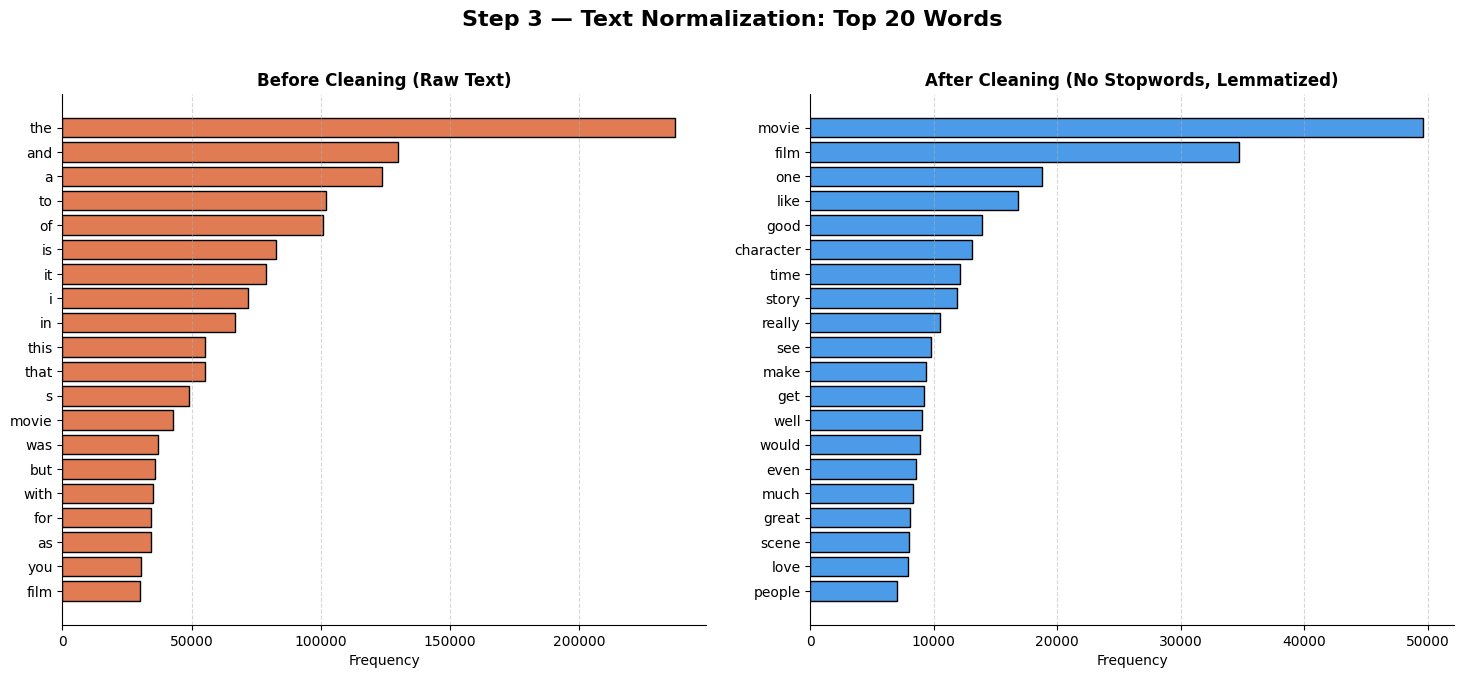

In [ ]:
before_top = get_top_words(df["Reviews"], n=20, filter_stopwords=False)
after_top = get_top_words(df["Reviews_cleaned"], n=20, filter_stopwords=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle("Step 3 — Text Normalization: Top 20 Words",
             fontsize=16, fontweight="bold", y=0.98)

words_b, counts_b = zip(*before_top)
axes[0].barh(words_b[::-1], counts_b[::-1], color="#E07B54", edgecolor="black")
axes[0].set_title("Before Cleaning (Raw Text)", fontweight="bold")
axes[0].set_xlabel("Frequency")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(axis="x", linestyle="--", alpha=0.5)

words_a, counts_a = zip(*after_top)
axes[1].barh(words_a[::-1], counts_a[::-1], color="#4C9BE8", edgecolor="black")
axes[1].set_title("After Cleaning (No Stopwords, Lemmatized)", fontweight="bold")
axes[1].set_xlabel("Frequency")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout(pad=2.0)
plt.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.close()
print(f"[Chart] Saved -> {CHART_FILE}")

df["genres"] = df["genres"].apply(lambda g: str(g))

df.to_csv(OUTPUT_FILE, index=False)
print(f"\n[Export] Saved -> {OUTPUT_FILE}  ({len(df):,} rows)")
print("\n[Done]  Step 3 complete.\n")


In [ ]:
df["genres"] = df["genres"].apply(lambda g: str(g))

output_filename = "reviews_step3_normalized.csv"
df.to_csv(output_filename, index=False)
print(f"\n[Export] Saved -> {output_filename}  ({len(df):,} rows)")
print("\n[Done]  Step 3 complete.\n")


[Export] Saved -> reviews_step3_normalized.csv  (19,316 rows)

[Done]  Step 3 complete.

